In [17]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import torch.nn.functional as F
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import os
from google.colab import userdata
from sklearn.metrics import roc_auc_score, average_precision_score
from huggingface_hub import login, whoami

In [18]:
!pip install -q huggingface_hub

In [ ]:
login(token="")
print(whoami())

{'type': 'user', 'id': '6910bc358c5b066775f910cb', 'name': 'ejmal', 'fullname': 'ejmal', 'isPro': False, 'avatarUrl': '/avatars/7655c1f9a2c6d5aa19610db8c6ccb776.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'colab-epr', 'role': 'fineGrained', 'createdAt': '2025-11-09T16:14:41.705Z', 'fineGrained': {'canReadGatedRepos': True, 'global': [], 'scoped': [{'entity': {'_id': '6910bc358c5b066775f910cb', 'type': 'user', 'name': 'ejmal'}, 'permissions': []}]}}}}


In [ ]:
hf_token = ''

model_google = "google/gemma-3-1b-it"
model_microsoft = "microsoft/phi-1_5"

In [21]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
#Telechargement du dataset IMDb
path_movies = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("IMDb path:", path_movies)
print("\nFiles in IMDb dataset folder:")
print(os.listdir(path_movies))

# Chargement du CSV IMDb
df_movies = pd.read_csv(os.path.join(path_movies, "IMDB Dataset.csv"))
print("IMDb Movie Reviews sample:")
display(df_movies.head())

# Telechargement du dataset Toxic Comments (Jigsaw)

df_toxic = pd.read_csv("/content/drive/My Drive/A3/PROCOM/toxic.csv")
#df_toxic = pd.read_csv("toxic.csv")
print(df_toxic.shape)
df_toxic.head()

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
IMDb path: /kaggle/input/imdb-dataset-of-50k-movie-reviews

Files in IMDb dataset folder:
['IMDB Dataset.csv']
IMDb Movie Reviews sample:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


(159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [23]:
df_toxic = df_toxic.drop(['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'], axis=1)
map_sentiment = {"positive" : 1, "negative" : 0}

def sample_balanced(df, label_col, n_total=500, random_state=42):
    """
    Sample n_total rows evenly across label classes.
    """

    n_classes = df[label_col].nunique()
    n_per_class = n_total // n_classes

    # Sample evenly
    df_balanced = (
        df.groupby(label_col, group_keys=False)
          .apply(lambda x: x.sample(n=min(len(x), n_per_class), random_state=random_state))
          .reset_index(drop=True)
          .sample(frac=1, random_state=random_state)
          .reset_index(drop=True)
    )

    print(f"Sampled {len(df_balanced)} rows ({n_per_class} per class).")
    return df_balanced

df_toxic_balanced = sample_balanced(df_toxic, label_col='toxic', n_total=1000)
df_movies_balanced = sample_balanced(df_movies, label_col='sentiment', n_total=150)
df_movies_balanced["sentiment"] = df_movies_balanced["sentiment"].map(map_sentiment)


# --- Preview ---
print("\n Toxic Balanced Sample:")
display(df_toxic_balanced.head())

print("\n IMDb Balanced Sample:")
display(df_movies_balanced.head())

Sampled 1000 rows (500 per class).
Sampled 150 rows (75 per class).

 Toxic Balanced Sample:


/tmp/ipython-input-1872779360.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), n_per_class), random_state=random_state))
/tmp/ipython-input-1872779360.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), n_per_class), random_state=random_state))


,id,comment_text,toxic
0,649995ad095fc18a,Your ass can hold them quite easily.,1
1,c945cad7fafbdf7e,"Suck dick faggot, you're full of yourself. 71....",1
2,6b6b04e577a35fd5,Stop\nStop screwing Chopin's birthday you uned...,1
3,750802cd3eb944e3,"Add to wikipedia\n\nHi Blotto adrift, why dont...",1
4,3c866dfaa4dc5447,Discussion at Talk:Contemporary Paganism#Move...,0



 IMDb Balanced Sample:


,review,sentiment
0,Well I just paid a dollar for a DVD of this mo...,0
1,I was looking forward to Kathryn Bigelow's mov...,0
2,When i first saw the movie being advertised i ...,1
3,What is there to say about an anti-establishme...,1
4,For a long time it seemed like all the good Ca...,1


In [24]:
def ask_LLM_abt_dataset(
    model_name,
    query_qst,   # ignoré maintenant
    dataset,
    text_col="review",
    hf_token=None,
    top_k=20,
    max_new_tokens=20,
):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token)
    model = AutoModelForCausalLM.from_pretrained(model_name, token=hf_token).to(device)
    model.eval()

    df = dataset.copy()
    df["EPR"] = 0.0
    df["LLM_response"] = ""
    df["output_length"] = 0

    for i, text in enumerate(df[text_col]):

        # --- CHANGEMENT ICI : utiliser le prompt structuré ---
        prompt = build_prompt(text)

        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=0.3,
                return_dict_in_generate=True,
                output_scores=True
            )

        generated_ids = outputs.sequences[0][inputs["input_ids"].shape[1]:]
        generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)

        # ----------- ENTROPY TOP-K --------------
        total_ent = 0.0
        num_steps = len(outputs.scores)

        for score in outputs.scores:
            probs = F.softmax(score, dim=-1)
            top_probs, _ = torch.topk(probs, k=top_k)
            safe_probs = torch.clamp(top_probs, min=1e-9)

            ent = -(safe_probs * torch.log2(safe_probs)).sum().item()
            total_ent += ent

        if num_steps > 0:
            df.at[i, "EPR"] = total_ent / num_steps
            df.at[i, "output_length"] = num_steps

        # --- CHANGEMENT ICI : extraction robuste JSON ---
        clean = safe_extract_label(generated_text)
        df.at[i, "LLM_response"] = clean

        if (i + 1) % 10 == 0:
            print(f"Processed {i+1}/{len(df)}")

    return df



In [25]:

import json
import re

def safe_extract_label(generated_text):
    """
    Extract {"label": "..."} from possibly messy LLM output.
    """
    text = generated_text.strip().lower()

    # Extract { ... } pattern first
    match = re.search(r"\{.*?\}", text)
    if match:
        try:
            obj = json.loads(match.group())
            if obj.get("label") in ["positive", "negative"]:
                return obj["label"]
        except:
            pass

    # Fallback regex
    match = re.search(r"\bpositive\b|\bnegative\b", text)
    if match:
        return match.group()

    return "unknown"


In [26]:
def build_prompt(review):
    return (
        "<bos><start_of_turn>user\n"
        "Classify the following movie review.\n"
        "Respond ONLY with one JSON object:\n"
        '{"label": "positive"} or {"label": "negative"}.\n'
        "Review:\n"
        f"{review}\n"
        "<end_of_turn>\n"
        "<start_of_turn>model\n"
    )



In [ ]:
df_movies_balanced_result = ask_LLM_abt_dataset(
    model_name=model_google,
    query_qst="ignored",
    dataset=df_movies_balanced,
    text_col="review",
    top_k=10,
    max_new_tokens=15
)

df_movies_balanced_result["true_label_text"] = df_movies_balanced_result["sentiment"].map({1: "positive", 0: "negative"})

display(df_movies_balanced_result[["review", "true_label_text", "LLM_response", "EPR"]].head())



Processed 10/150
Processed 20/150
Processed 30/150
Processed 40/150
Processed 50/150
Processed 60/150
Processed 70/150
Processed 80/150
Processed 90/150
Processed 100/150
Processed 110/150
Processed 120/150
Processed 130/150
Processed 140/150
Processed 150/150


,review,true_label_text,LLM_response,EPR
0,Well I just paid a dollar for a DVD of this mo...,negative,negative,2.690762e-07
1,I was looking forward to Kathryn Bigelow's mov...,negative,negative,2.690762e-07
2,When i first saw the movie being advertised i ...,positive,positive,2.690762e-07
3,What is there to say about an anti-establishme...,positive,positive,2.690762e-07
4,For a long time it seemed like all the good Ca...,positive,positive,2.690762e-07


In [ ]:
# Calculer l'accuracy:
# Convertir les labels texte en 0/1 pour comparaison
map_pred = {"positive": 1, "negative": 0}

df_movies_balanced_result["pred_label"] = df_movies_balanced_result["LLM_response"].map(map_pred)

df_movies_balanced_result["correct"] = (df_movies_balanced_result["pred_label"] == df_movies_balanced_result["sentiment"]).astype(int)

# Calcul de l'accuracy
accuracy = df_movies_balanced_result["correct"].mean()

print(f"Accuracy du modèle : {accuracy:.4f}")


Accuracy du modèle : 0.9333



=== Évaluation de Google-Gemma sur IMDb ===

----> Calcul pour top_k = 15
Processed 10/150
Processed 20/150
Processed 30/150
Processed 40/150
Processed 50/150
Processed 60/150
Processed 70/150
Processed 80/150
Processed 90/150
Processed 100/150
Processed 110/150
Processed 120/150
Processed 130/150
Processed 140/150
Processed 150/150

=== Résumé EPR ===
          model dataset   k  mean_EPR_correct  mean_EPR_incorrect      ΔEPR  \
0  Google-Gemma    IMDb  15          0.007346            0.023514  0.016168   

   AUC(EPR)  
0  0.617809  


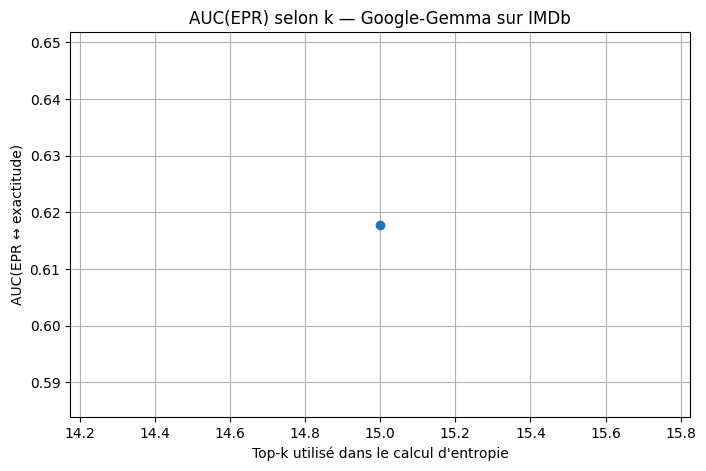

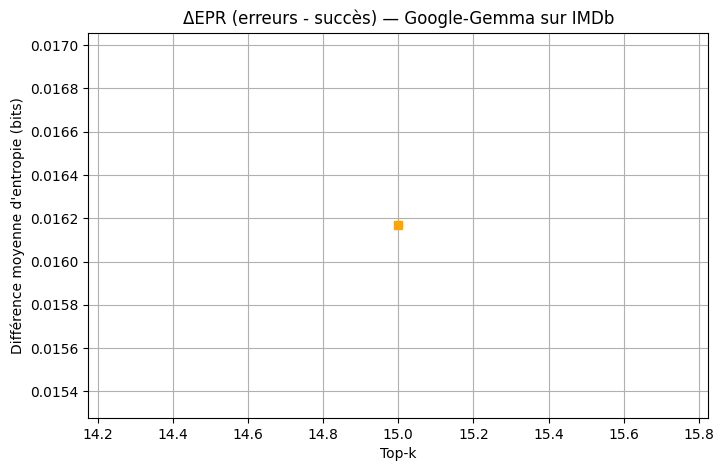


=== Conclusions ===
→ Google-Gemma sur IMDb : meilleur k = 15, AUC(EPR) = 0.618, ΔEPR = 0.016 bits


In [29]:
#Stat sur l'EPR
import matplotlib.pyplot as plt

# Valeurs top-k
TOP_K_VALUES = [15]

# Modèles à évaluer
MODELS = {
    "Google-Gemma": model_google
}

# Jeux de données à évaluer
DATASETS = {
    "IMDb": (df_movies_balanced, "ignored", "review", "sentiment")
}


# =====================================================
#     FONCTION D'ÉVALUATION COMPATIBLE AVEC NOUVEAU CODE
# =====================================================

def evaluate_model_on_dataset(model_label, model_name, dataset_name, df_base, query_qst, text_col, label_col):
    results = []
    print(f"\n=== Évaluation de {model_label} sur {dataset_name} ===")

    for k in TOP_K_VALUES:
        print(f"\n----> Calcul pour top_k = {k}")

        df_k = ask_LLM_abt_dataset(
            model_name=model_name,
            query_qst="ignored",
            dataset=df_base,
            text_col=text_col,
            top_k=k,
            max_new_tokens=15
        )

        df_k["model"] = model_label
        df_k["dataset"] = dataset_name
        df_k["k"] = k
        df_k["label"] = df_k[label_col]   # vrai label 0/1

        results.append(df_k)

    return pd.concat(results, ignore_index=True)



# =====================================================
#       BOUCLE PRINCIPALE D'ÉVALUATION
# =====================================================

all_results = []
for model_label, model_name in MODELS.items():
    for dataset_name, (df_data, query_qst, text_col, label_col) in DATASETS.items():

        df_out = evaluate_model_on_dataset(
            model_label,
            model_name,
            dataset_name,
            df_data,
            query_qst,
            text_col,
            label_col
        )

        all_results.append(df_out)

df_all = pd.concat(all_results, ignore_index=True)



# =====================================================
#   EXTRACTION DES PREDICTIONS (LLM_response → 0/1)
# =====================================================

def extract_pred_label(resp):
    if resp == "positive":
        return 1
    if resp == "negative":
        return 0
    return -1   # unknown → incorrect automatiquement

df_all["pred_label"] = df_all["LLM_response"].apply(extract_pred_label)
df_all["correct"] = (df_all["pred_label"] == df_all["label"]).astype(int)



# =====================================================
#   RÉSUMÉ EPR + AUC
# =====================================================

summary = []
for (model, dataset, k), subset in df_all.groupby(["model", "dataset", "k"]):

    mean_epr_correct = subset[subset["correct"] == 1]["EPR"].mean()
    mean_epr_incorrect = subset[subset["correct"] == 0]["EPR"].mean()
    delta = mean_epr_incorrect - mean_epr_correct

    auc_val = roc_auc_score(
        subset["correct"],
        -subset["EPR"]
    ) if subset["correct"].nunique() > 1 else None

    summary.append({
        "model": model,
        "dataset": dataset,
        "k": k,
        "mean_EPR_correct": mean_epr_correct,
        "mean_EPR_incorrect": mean_epr_incorrect,
        "ΔEPR": delta,
        "AUC(EPR)": auc_val
    })

summary_df = pd.DataFrame(summary)

print("\n=== Résumé EPR ===")
print(summary_df)



# =====================================================
#   GRAPHIQUES
# =====================================================

for (model, dataset), group in summary_df.groupby(["model", "dataset"]):

    plt.figure(figsize=(8, 5))
    plt.plot(group["k"], group["AUC(EPR)"], marker="o")
    plt.title(f"AUC(EPR) selon k — {model} sur {dataset}")
    plt.xlabel("Top-k utilisé dans le calcul d'entropie")
    plt.ylabel("AUC(EPR ↔ exactitude)")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(group["k"], group["ΔEPR"], marker="s", color="orange")
    plt.title(f"ΔEPR (erreurs - succès) — {model} sur {dataset}")
    plt.xlabel("Top-k")
    plt.ylabel("Différence moyenne d'entropie (bits)")
    plt.grid(True)
    plt.show()



# =====================================================
#   CONCLUSION : meilleur k
# =====================================================

best = summary_df.loc[
    summary_df.groupby(["model", "dataset"])["AUC(EPR)"].idxmax()
]

print("\n=== Conclusions ===")
for _, row in best.iterrows():
    print(
        f"→ {row['model']} sur {row['dataset']} : "
        f"meilleur k = {row['k']}, "
        f"AUC(EPR) = {row['AUC(EPR)']:.3f}, "
        f"ΔEPR = {row['ΔEPR']:.3f} bits"
    )


In [32]:
# Convertir le vrai label en texte
df_all["true_label_text"] = df_all["sentiment"].map({1: "positive", 0: "negative"})

# Afficher quelques exemples
cols = ["review", "true_label_text", "LLM_response", "EPR"]
display(df_all[cols].head(10))


,review,true_label_text,LLM_response,EPR
0,Well I just paid a dollar for a DVD of this mo...,negative,negative,4.185630e-07
1,I was looking forward to Kathryn Bigelow's mov...,negative,negative,4.185630e-07
2,When i first saw the movie being advertised i ...,positive,positive,4.185630e-07
3,What is there to say about an anti-establishme...,positive,positive,4.185630e-07
4,For a long time it seemed like all the good Ca...,positive,positive,4.185630e-07
5,And obviously I didn't see it! <br /><br />But...,negative,negative,4.185630e-07
6,I'll keep this short as a movie like this does...,negative,negative,4.185630e-07
7,I rented this obscure aussie relic a few years...,positive,positive,4.185630e-07
8,This movie was childish in its writing and lau...,negative,negative,4.185630e-07
9,Why this movie has all but disappeared into ob...,positive,positive,4.185630e-07


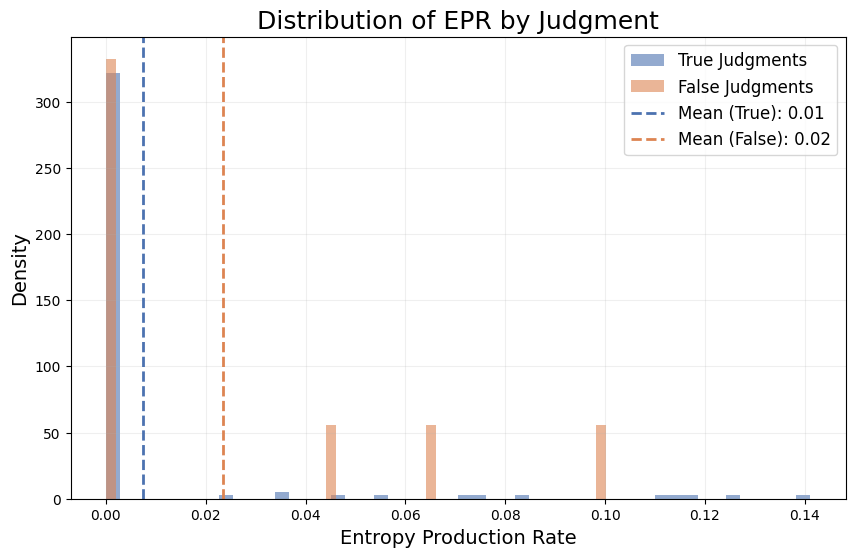

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Séparer les cas corrects / incorrects
correct_epr = df_all[df_all["correct"] == 1]["EPR"]
incorrect_epr = df_all[df_all["correct"] == 0]["EPR"]

# Moyennes
mean_correct = correct_epr.mean()
mean_incorrect = incorrect_epr.mean()

plt.figure(figsize=(10, 6))

# Histogrammes (densité vraie)
plt.hist(correct_epr, bins=50, density=True, alpha=0.6, label="True Judgments", color="#4C72B0")
plt.hist(incorrect_epr, bins=50, density=True, alpha=0.6, label="False Judgments", color="#DD8452")

# Lignes verticales des moyennes
plt.axvline(mean_correct, color="#4C72B0", linestyle="--", linewidth=2,
            label=f"Mean (True): {mean_correct:.2f}")
plt.axvline(mean_incorrect, color="#DD8452", linestyle="--", linewidth=2,
            label=f"Mean (False): {mean_incorrect:.2f}")

# Labels et titre
plt.title("Distribution of EPR by Judgment", fontsize=18)
plt.xlabel("Entropy Production Rate", fontsize=14)
plt.ylabel("Density", fontsize=14)

plt.legend(fontsize=12)
plt.grid(alpha=0.2)

plt.show()
